
# Fitting RHESSI Spectra


## Example of Fitting RHESSI Spectra

This notebook provides a quick overlook of the fitting code in sunkit-spex and some real examples of fitting RHESSI
spectra that can be compared to published works.

Try fitting the spectra presented in [Fletcher2007]_ an M1.2 flare which occurred on 2002 October 5.

**For a more explained demonstration of the general fitting process and capabilities see the NuSTAR fitting example.**


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from numpy.exceptions import VisibleDeprecationWarning
from parfive import Downloader

from astropy.time import Time

from sunkit_spex.extern.rhessi import RhessiLoader
from sunkit_spex.legacy.fitting.fitter import Fitter

warnings.filterwarnings("ignore", category=RuntimeWarning)
try:
    warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)
except AttributeError:
    warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

Download the example data



In [2]:
# dl = Downloader()
# base_url = "https://homepages.dias.ie/smaloney/sunkit-spex/rhessi/"
# file_names = ["20021005_103800_spec.fits", "20021005_103800_srm.fits"]

# for fname in file_names:
#     dl.enqueue_file(base_url + fname, path="data/")
# files = dl.download()

Set up some plotting numbers



In [3]:
time_profile_size = (9, 6)
spec_plot_size = (6, 6)
tol = 1e-5
spec_font_size = 18
default_text = 10
xlims, ylims = [3, 100], [5e-4, 1e4]

Load in the data...



In [4]:
rhess_spec = RhessiLoader(
    spectrum_fn="data/20021005_103800_spec.fits", srm_fn="data/20021005_103800_srm.fits"
)

To see what we have, we can plot the time profile. The whole file time is taken as the event time as default
(indicated by purple shaded region).

We do this by accessing the RHESSI spectral loader in the `ress_spec.loaded_spec_data` dictionary.
Since the RHESSI spectrum is the only one loaded it is under the `"spectrum1"` entry.

Default energy range plotted is all energies but the user can define an energy rangem or ranges.
Ranges are inclusive at the bounds and here we see the 5$-$10 keV, 10$-$30 keV, and 25$-$50 keV ranges.



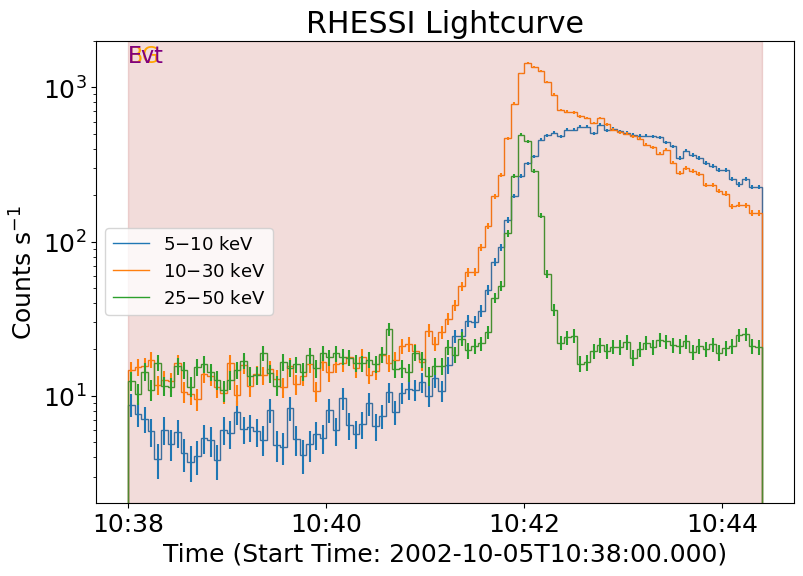

In [5]:
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=time_profile_size)

# the line that actually plots
rhess_spec.lightcurve(energy_ranges=[[5, 10], [10, 30], [25, 50]])

plt.show()
plt.rcParams["font.size"] = default_text

Since the default event data is assumed to be the full time, we might want to change this.
We also define a background time too and plot again.

Both need to be set, if one is None (default) then no background will be calculated or will be removed



In [6]:
rhess_spec.update_background_times(Time("2002-10-05T10:38:32"), Time("2002-10-05T10:40:32"))

# event time
rhess_spec.update_event_times(Time("2002-10-05T10:41:20"), Time("2002-10-05T10:42:24"))

Plot again



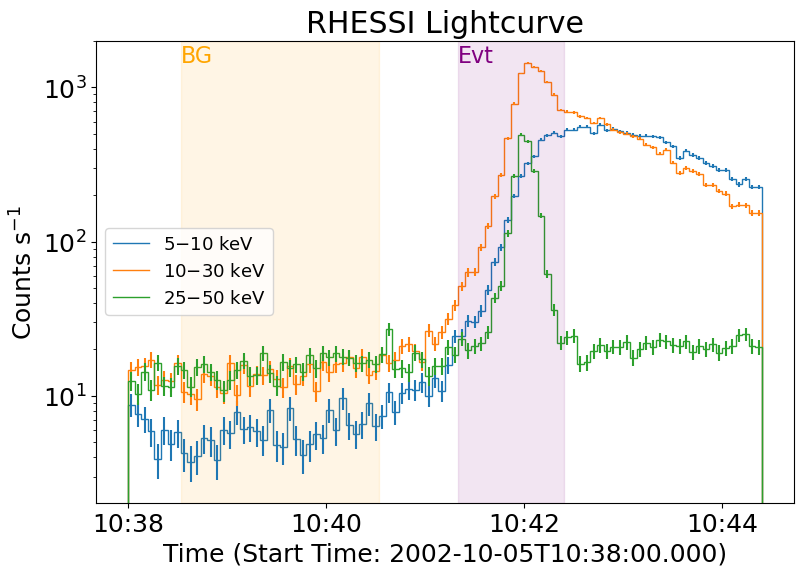

In [7]:
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=time_profile_size)
rhess_spec.lightcurve(energy_ranges=[[5, 10], [10, 30], [25, 50]])
plt.show()
plt.rcParams["font.size"] = default_text

We can also see the X-ray evolution via a spectrogram.



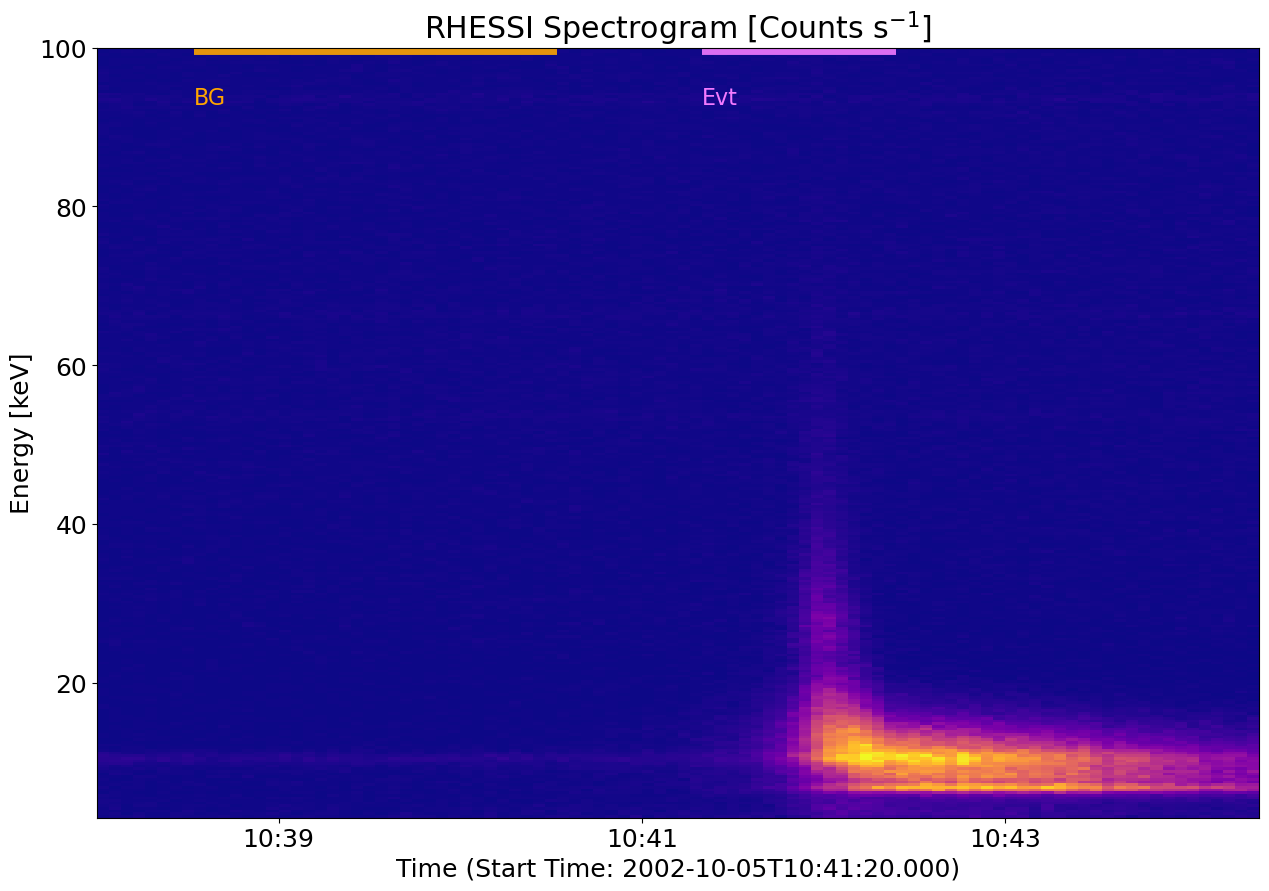

In [8]:
# plot spectrogram
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=(15, 10))
rhess_spec.spectrogram()
plt.show()
plt.rcParams["font.size"] = default_text

Now let's get going with a model and explicitly stating a fit statistic



In [9]:
fitter = Fitter(rhess_spec)

fitter.model = "(f_vth+thick_fn)"
fitter.loglikelihood = "cstat"

See what parameters we have to play with:



In [10]:
fitter.show_params

Param,Status,Value,Bounds,Error
,,,"(min, max)","(-, +)"
str22,str11,float64,object,object
T1_spectrum1,free,1.00e+00,"(0.0, None)","( 0.00e+00, 0.00e+00)"
EM1_spectrum1,free,1.00e+00,"(0.0, None)","( 0.00e+00, 0.00e+00)"
total_eflux1_spectrum1,free,1.00e+00,"(0.0, None)","( 0.00e+00, 0.00e+00)"
index1_spectrum1,free,1.00e+00,"(0.0, None)","( 0.00e+00, 0.00e+00)"
e_c1_spectrum1,free,1.00e+00,"(0.0, None)","( 0.00e+00, 0.00e+00)"
Fit Stat.,cstat ln(L),0.00e+00,--,--


Looking at the spectrum, define sensible numbers for starting values (maybe some trial and error here).

For this sepctrum, we will fit the thermal and non-thermal model over different energy ranges separately then both
over the full range.

We fit the thermal model from 6$-$15 keV and fix the non-thermal model parameters.



In [11]:
fitter.energy_fitting_range = [6, 15]

# sort model parameters
fitter.params["T1_spectrum1"] = {"Value": 50, "Bounds": (15, 99)}
fitter.params["EM1_spectrum1"] = {"Value": 2e1, "Bounds": (1e0, 1e4)}
fitter.params["total_eflux1_spectrum1"] = {"Status": "fix", "Value": 0.9, "Bounds": (1e-1, 1e1)}
fitter.params["index1_spectrum1"] = {"Status": "fix", "Value": 6, "Bounds": (3, 1e1)}
fitter.params["e_c1_spectrum1"] = {"Status": "fix", "Value": 2e1, "Bounds": (1e1, 1e2)}

Now perform the fit.



In [12]:
rhess_spec_fit = fitter.fit(tol=tol)

Fix thermal parameters and free non-thermal parameters and fit over 15$-$45 keV.



In [13]:
fitter.energy_fitting_range = [15, 45]

# sort model parameters
fitter.params["T1_spectrum1"] = "fix"
fitter.params["EM1_spectrum1"] = "fix"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"

Do the fit



In [14]:
rhess_spec_fit = fitter.fit(tol=tol)

Free all parameters and fit over 6$-$45 keV.



In [15]:
# define energy fitting range
fitter.energy_fitting_range = [6, 45]

# sort model parameters
fitter.params["T1_spectrum1"] = "free"
fitter.params["EM1_spectrum1"] = "free"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"

Fit



In [16]:
rhess_spec_fit = fitter.fit(tol=tol)

Let's plot the result. Since a background has been set it will be displayed in grey behind all other models and data.



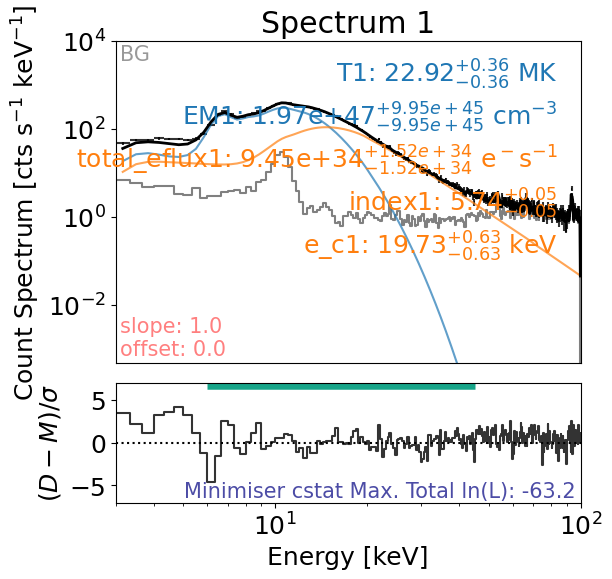

In [17]:
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_plot_size)

# the line that actually plots
axes, res_axes = fitter.plot()

# make plot nicer
for a in axes:
    a.set_xlim(xlims)
    a.set_ylim(ylims)
    a.set_xscale("log")
plt.show()
plt.rcParams["font.size"] = default_text

## How is the background included when fitting?

By default the (time scaled) background is added to the model then compared to the event data (i.e., fitting the event data with background+model). This is the recommended approach, especially since we're dealing with Poisson statistics.

However, this has been difficult in the past in software like OSPEX and so fitting usually been done by subtracting the background from the event time and fitting the model to the result (i.e., fitting the event-background with the model). To replicate this method we make use of the `data2data_minus_background` setter; we set this to True.



In [18]:
# fitter.data.loaded_spec_data["spectrum1"].data2data_minus_background = True
fitter.data.loaded_spec_data["spectrum1"].subtract_background = True

The data being fitted then becomes event-background and a dictionary key is set to make sure that the background is
not included in the fitting process. Fitting continues as normal as though there is not background.

We then reset the parameter starting values, perform the fit, and plot again.



In [19]:
# define energy fitting range
fitter.energy_fitting_range = [6, 15]

# sort model parameters
fitter.params["T1_spectrum1"] = {"Value": 50, "Bounds": (15, 99)}  # 22
fitter.params["EM1_spectrum1"] = {"Value": 2e1, "Bounds": (1e0, 1e2)}  # 20
fitter.params["total_eflux1_spectrum1"] = {"Status": "fix", "Value": 0.9, "Bounds": (1e-1, 1e1)}
fitter.params["index1_spectrum1"] = {"Status": "fix", "Value": 6, "Bounds": (3, 1e1)}
fitter.params["e_c1_spectrum1"] = {"Status": "fix", "Value": 2e1, "Bounds": (1e1, 1e2)}

Fit



In [20]:
fitter.fit(tol=tol)

# define energy fitting range
fitter.energy_fitting_range = [15, 45]

# sort model parameters
fitter.params["T1_spectrum1"] = "fix"
fitter.params["EM1_spectrum1"] = "fix"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"

# fit
fitter.fit(tol=tol)

# define energy fitting range
fitter.energy_fitting_range = [6, 45]

# sort model parameters
fitter.params["T1_spectrum1"] = "free"
fitter.params["EM1_spectrum1"] = "free"
fitter.params["total_eflux1_spectrum1"] = "free"
fitter.params["index1_spectrum1"] = "free"
fitter.params["e_c1_spectrum1"] = "free"

# fit
fitter.fit(tol=tol)

[22.114113667919042,
 100.0,
 0.8728076924311496,
 3.56483694234392,
 10.00000589468327]

Plot again plot



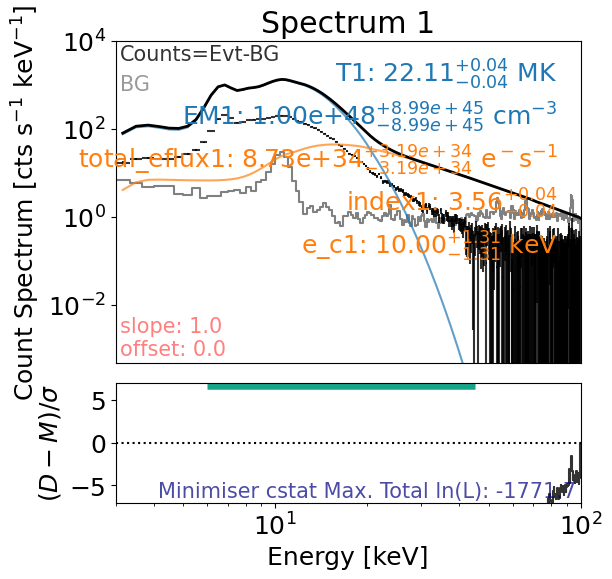

In [21]:
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_plot_size)

# the line that actually plots
axes, res_axes = fitter.plot()

# make plot nicer
for a in axes:
    a.set_xlim(xlims)
    a.set_ylim(ylims)
    a.set_xscale("log")
plt.show()
plt.rcParams["font.size"] = default_text

As we can see, there is a "Counts=Evt-BG" tag added in the top left corner of the plot along with the BG grey label to
indicate that the counts being fitted are calculated from the background subtracted event data.

If the user wishes to undo this and wants to return to using the model+background fitting the event method then set
`data2data_minus_background` back to False like so.



In [22]:
# fitter.data.loaded_spec_data["spectrum1"].data2data_minus_background = False
fitter.data.loaded_spec_data["spectrum1"].subtract_background = False

Any change to the background time and the `data2data_minus_background` setter will be set back to False.
Therefore, if the user changes the background times at all and still wants the event-background method then the
`data2data_minus_background` setter must be set to True again.

## Running an MCMC

Run the MCMC.



In [23]:
rhess_spec_mcmc = fitter.run_mcmc(steps_per_walker=1000,walker_spread='mag_order')

100%|██████████| 1000/1000 [01:25<00:00, 11.76it/s]


Look at the detailed MCMC results.



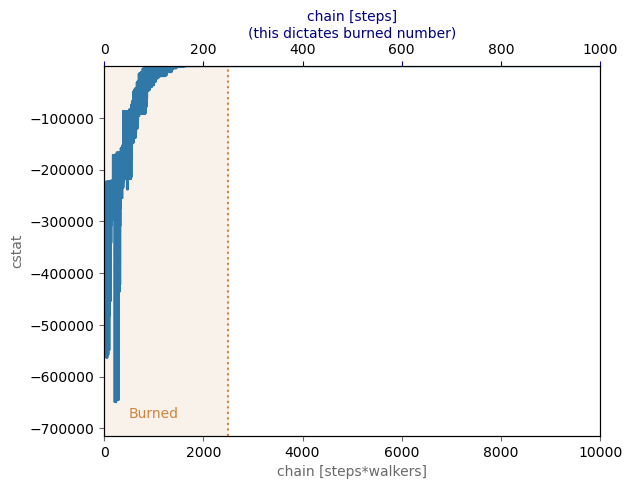

In [24]:
# burn the run in phase
fitter.burn_mcmc = 250

# look if the log probability chain has settled and decide if the number of samples burned was appropriate
plt.figure()
fitter.plot_log_prob_chain()
# plt.ylim([-80, -60])
plt.show()

Produce a corner plot



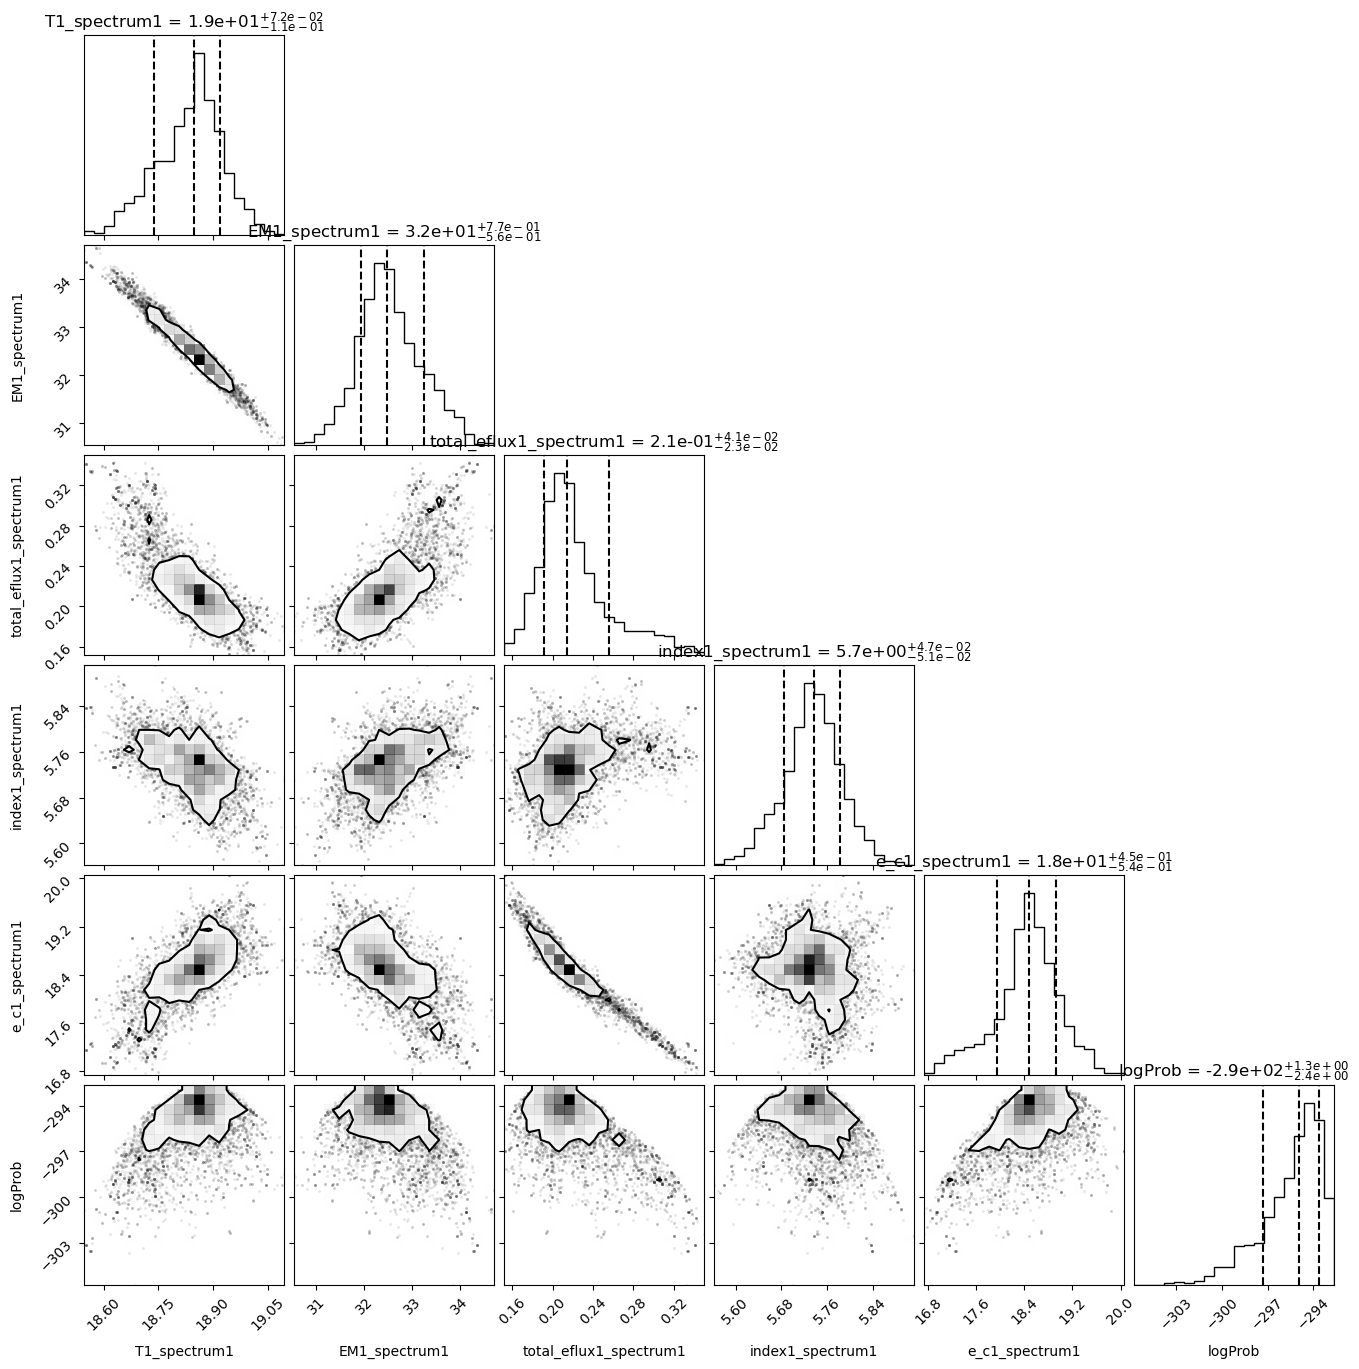

In [25]:
corner_plot_ress_spec = fitter.corner_mcmc()

Plot final spectral results.



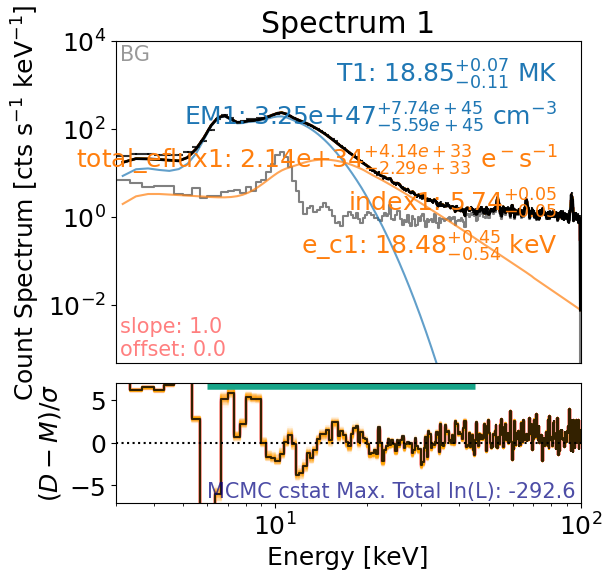

In [26]:
# start plot
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_plot_size)

# the line that actually plots
axes, res_axes = fitter.plot()

# make plot nicer
for a in axes:
    a.set_xlim(xlims)
    a.set_ylim(ylims)
    a.set_xscale("log")
plt.show()
plt.rcParams["font.size"] = default_text

## Save out session




In [27]:
save_filename = "data/sunxspexRhessiSpectralFitting.pickle"
fitter.save(save_filename)

## Loading session back in
The session can be loaded back in using the following code as an example,


```python
from sunkit_spex.sunxspex_fitting.fitter import load

rhessi_reloaded = load(save_filename)
```


## Comparisons

| Model Parameter | OSPEX (Fletcher et al. 2007) | Recent OSPEX Fit (from Iain Hannah) | This Work (Minimize Soln, evt-bg) | This Work (Minimize Soln) | This Work (MCMC) |
|---|---|---|---|---|---|
| Temperature [MK] | 24.13 | 22.45 | $22.7 \pm 0.1$ | $22.9 \pm 0.1$ | $22.71^{+0.29}_{-0.34}$ |
| Emission Measure [$\mathrm{cm}^{-3}$] | $1.6 \times 10^{47}$ | $2.0 \times 10^{47}$ | $(1.92 \pm 0.05) \times 10^{47}$ | $(1.90 \pm 0.04) \times 10^{47}$ | $1.83^{+0.09}_{-0.08} \times 10^{47}$ |
| Electron Flux [$\mathrm{e}^{-}\,\mathrm{s}^{-1}$] |  | $9.8 \times 10^{34}$ | $(8.8 \pm 0.2) \times 10^{34}$ | $(8.5 \pm 0.2) \times 10^{34}$ | $8.5^{+1.1}_{-1.2} \times 10^{34}$ |
| Index |  | 5.77 | $5.70 \pm 0.05$ | $5.71 \pm 0.05$ | $5.65^{+0.06}_{-0.04}$ |
| Low Energy Cut-off [keV] |  | 19.44 | $19.8 \pm 0.1$ | $19.9 \pm 0.1$ | $19.8^{+0.6}_{-0.5}$ |

*Fletcher et al. (2007):* spectrum fit with a broken power-law model approximating the thick target model.

Reference: https://iopscience.iop.org/article/10.1086/510446